# Pattern Recognition and Machine Learning (EE602L)
## Lab 2: Regression, Parameter Estimation and Regularization

**Roll No:** EC24BT033

**Dataset:** `housing.csv` (California Housing, 1990 U.S. Census). Each row is one census district; the target is `median_house_value`.

<style>pre, code { white-space: pre-wrap !important; word-break: break-word; }</style>

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# When running on Google Colab, download the dataset directly:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

## Data Preparation (common to both parts)

### 1. Inspect

In [2]:
print("Shape (rows, cols):", df.shape)
print("\nData types:")
print(df.dtypes)

Shape (rows, cols): (20640, 10)

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nocean_proximity categories:")
print(df["ocean_proximity"].value_counts().to_string())
print("\nRows with target capped at 500001:", (df["median_house_value"] == 500001).sum())

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0

Duplicate rows: 0

ocean_proximity categories:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5

Rows with target capped at 500001: 965


**Findings:** N = 20,640 rows, 10 columns (9 numeric + 1 categorical). Only `total_bedrooms` has missing values (207). There are no duplicate rows. The target `median_house_value` was capped by the census at \$500,001, and 965 districts sit exactly at that cap; we keep these rows (they are real districts, and dropping ~5% of the data would bias the model against expensive areas) but note that the cap censors the target, so the model can never predict above it correctly.

### 2. Visualize before modelling

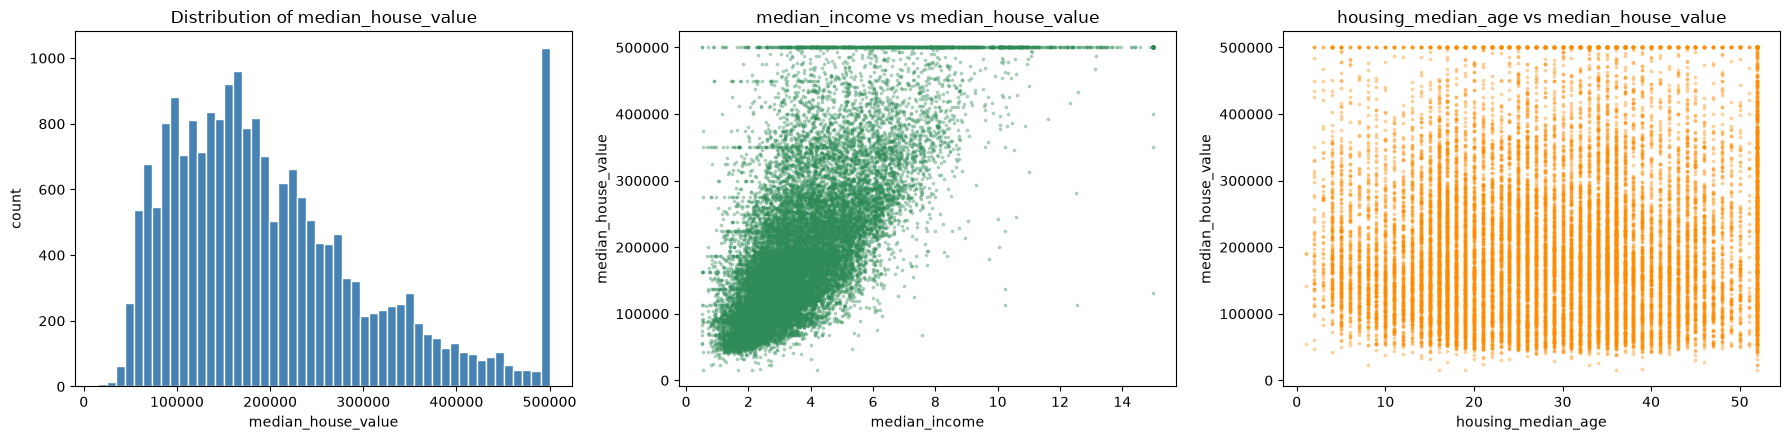

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Distribution of the target
axes[0].hist(df["median_house_value"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of median_house_value")
axes[0].set_xlabel("median_house_value"); axes[0].set_ylabel("count")

# Target vs the strongest predictor
axes[1].scatter(df["median_income"], df["median_house_value"], s=3, alpha=0.3, color="seagreen")
axes[1].set_title("median_income vs median_house_value")
axes[1].set_xlabel("median_income"); axes[1].set_ylabel("median_house_value")

# Target vs a weaker feature
axes[2].scatter(df["housing_median_age"], df["median_house_value"], s=3, alpha=0.3, color="darkorange")
axes[2].set_title("housing_median_age vs median_house_value")
axes[2].set_xlabel("housing_median_age"); axes[2].set_ylabel("median_house_value")

plt.tight_layout()
plt.show()

The target is right-skewed with a visible spike at the \$500,001 cap (the censoring). `median_income` shows a clear, roughly linear positive relationship with the target, so it should be the dominant predictor. `housing_median_age` shows almost no trend on its own. The horizontal line of capped districts is visible in both scatters.

### 3. Encode the categorical column

`ocean_proximity` has 5 unordered categories, so we one-hot encode it (integer-coding would invent a fake ordering like INLAND < ISLAND). We use `drop_first=True`, which keeps 4 dummy columns: the dropped category (<1H OCEAN) becomes the baseline absorbed by the intercept, and this also avoids the dummy-variable trap (all 5 dummies always summing to 1 would be perfectly collinear with the intercept column).

In [7]:
df_enc = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

# get_dummies makes boolean columns; convert them to 0/1 integers
for col in df_enc.columns:
    if df_enc[col].dtype == bool:
        df_enc[col] = df_enc[col].astype(int)

print("Columns after encoding:")
print(list(df_enc.columns))

Columns after encoding:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


### 4. Split 70:15:15 (own implementation, no sklearn.model_selection)

Same approach as Lab 1: shuffle row positions with a seeded `np.random.permutation`, slice into three contiguous pieces (test takes the remainder so no row is lost to rounding), and verify disjointness with set intersections.

In [8]:
def custom_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Shuffle and split a dataframe into train/val/test using only NumPy/Pandas."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))

    n_train = int(train_ratio * len(df))
    n_val = int(val_ratio * len(df))

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]


train_df, val_df, test_df = custom_split(df_enc)
print(f"train: {len(train_df)} rows ({len(train_df)/len(df_enc):.1%})")
print(f"val:   {len(val_df)} rows ({len(val_df)/len(df_enc):.1%})")
print(f"test:  {len(test_df)} rows ({len(test_df)/len(df_enc):.1%})")

tr = set(train_df.index)
va = set(val_df.index)
te = set(test_df.index)
print("\noverlaps:", len(tr & va), len(tr & te), len(va & te))
assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE: splits overlap!"
assert len(tr | va | te) == len(df_enc), "rows lost or duplicated"
print("verified: splits are disjoint and cover all", len(df_enc), "rows")

train: 14447 rows (70.0%)
val:   3096 rows (15.0%)
test:  3097 rows (15.0%)

overlaps: 0 0 0
verified: splits are disjoint and cover all 20640 rows


### 5. Impute, handle outliers, standardize (training-set statistics only)

All three operations learn their numbers from the **training set only** and then apply them unchanged to validation and test, so no information from val/test leaks into preparation.

- **Imputation:** `total_bedrooms` missing values are filled with the *training* median (robust choice, consistent with Lab 1).
- **Outlier criterion (stated once, applied consistently):** we **cap (winsorize)** each numeric feature to the training set's 3xIQR extreme fences. Capping rather than removal because these are genuine districts (removal would throw away real signal, and we cannot remove rows from a test set we claim to predict on). The target is left untouched: it is already censored by the census cap and is not an input feature.
- **Standardization:** z-score using training mean and std for the numeric features. The 0/1 dummy columns are left unscaled (they are already on a comparable scale and keep their interpretation).

In [9]:
target_col = "median_house_value"
numeric_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]
dummy_cols = [c for c in df_enc.columns if c.startswith("ocean_proximity_")]
feature_cols = numeric_cols + dummy_cols

train_p = train_df.copy()
val_p = val_df.copy()
test_p = test_df.copy()

# 1. Impute total_bedrooms with the TRAIN median
train_median_tb = train_p["total_bedrooms"].median()
for part in [train_p, val_p, test_p]:
    part["total_bedrooms"] = part["total_bedrooms"].fillna(train_median_tb)
print("imputed total_bedrooms with train median =", train_median_tb)

# 2. Cap numeric features to the TRAIN 3xIQR extreme fences
print("\ncapping to train 3xIQR fences:")
for col in numeric_cols:
    q1 = train_p[col].quantile(0.25)
    q3 = train_p[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 3.0 * iqr
    hi = q3 + 3.0 * iqr
    n_capped = ((train_p[col] < lo) | (train_p[col] > hi)).sum()
    for part in [train_p, val_p, test_p]:
        part[col] = part[col].clip(lo, hi)
    print(f"  {col:20s} fences [{lo:11.2f}, {hi:11.2f}]  train rows capped: {n_capped}")

# 3. Standardize numeric features with TRAIN mean and std
train_means = train_p[numeric_cols].mean()
train_stds = train_p[numeric_cols].std()
for part in [train_p, val_p, test_p]:
    part[numeric_cols] = (part[numeric_cols] - train_means) / train_stds

print("\ntrain numeric features after scaling: mean ~0, std ~1")
print(train_p[numeric_cols].describe().loc[["mean", "std"]].round(3))

imputed total_bedrooms with train median = 435.0

capping to train 3xIQR fences:
  longitude            fences [    -133.17,     -106.64]  train rows capped: 0
  latitude             fences [      22.59,       49.05]  train rows capped: 0
  housing_median_age   fences [     -39.00,       94.00]  train rows capped: 0
  total_rooms          fences [   -3718.50,     8311.00]  train rows capped: 337
  total_bedrooms       fences [    -754.00,     1696.00]  train rows capped: 308
  population           fences [   -2041.00,     4553.00]  train rows capped: 297
  households           fences [    -705.00,     1591.00]  train rows capped: 283
  median_income        fences [      -3.96,       11.27]  train rows capped: 103

train numeric features after scaling: mean ~0, std ~1
      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
mean       -0.0       0.0                 0.0          0.0            -0.0   
std         1.0       1.0                 1.0          1.0        

In [10]:
# Final matrices used by both parts: X has an intercept column of ones in front
def make_X_y(part):
    X = part[feature_cols].to_numpy(dtype=float)
    ones = np.ones((len(X), 1))
    X = np.hstack([ones, X])
    y = part[target_col].to_numpy(dtype=float)
    return X, y

X_train, y_train = make_X_y(train_p)
X_val, y_val = make_X_y(val_p)
X_test, y_test = make_X_y(test_p)

param_names = ["intercept"] + feature_cols
print("X_train shape:", X_train.shape, " (first column is the intercept)")
print("p =", len(feature_cols), "predictors, excluding the intercept")

X_train shape: (14447, 13)  (first column is the intercept)
p = 12 predictors, excluding the intercept


## Part (a): MMSE Parameter Estimation vs Gradient Descent

### Closed-form MMSE solution

theta = (X^T X)^(-1) X^T y. We use `np.linalg.pinv` (the Moore-Penrose pseudo-inverse) instead of a plain matrix inverse: X^T X can be singular or nearly singular when features are highly correlated (which they are here, see Part b), and a plain inverse then blows up tiny rounding errors into huge coefficients or fails outright. The pseudo-inverse handles rank-deficient and ill-conditioned matrices stably by zeroing negligible singular values, giving the minimum-norm least-squares solution.

In [11]:
def fit_mmse(X, y):
    """Closed-form least squares via the pseudo-inverse."""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def predict(X, theta):
    return X @ theta

t0 = time.perf_counter()
theta_mmse = fit_mmse(X_train, y_train)
mmse_time = time.perf_counter() - t0
print(f"MMSE solve time: {mmse_time:.4f} s")

MMSE solve time: 0.0007 s


In [12]:
# Error metrics, implemented from scratch
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

def rmse(y, y_hat):
    return np.sqrt(mse(y, y_hat))

def mae(y, y_hat):
    return np.mean(np.abs(y - y_hat))

def r2(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def adj_r2(y, y_hat, p):
    n = len(y)
    return 1 - (1 - r2(y, y_hat)) * (n - 1) / (n - p - 1)

p = len(feature_cols)

def all_metrics(y, y_hat):
    return {"MSE": mse(y, y_hat), "RMSE": rmse(y, y_hat), "MAE": mae(y, y_hat),
            "R2": r2(y, y_hat), "Adj_R2": adj_r2(y, y_hat, p)}

train_pred = predict(X_train, theta_mmse)
val_pred = predict(X_val, theta_mmse)

results = pd.DataFrame({"train": all_metrics(y_train, train_pred),
                        "validation": all_metrics(y_val, val_pred)})
print("MMSE closed-form performance:")
print(results.round(4).to_string())

MMSE closed-form performance:
               train    validation
MSE     4.458392e+09  4.382131e+09
RMSE    6.677120e+04  6.619767e+04
MAE     4.874825e+04  4.838022e+04
R2      6.660000e-01  6.685000e-01
Adj_R2  6.657000e-01  6.672000e-01


In [13]:
# Learned parameters with their feature names
coef_table = pd.DataFrame({"parameter": param_names, "value": theta_mmse.round(2)})
print(coef_table.to_string(index=False))

                 parameter     value
                 intercept 219527.80
                 longitude -53565.67
                  latitude -54129.95
        housing_median_age  14078.21
               total_rooms -19400.42
            total_bedrooms  40686.11
                population -50465.50
                households  34079.04
             median_income  77597.98
    ocean_proximity_INLAND -36890.25
    ocean_proximity_ISLAND 126186.93
  ocean_proximity_NEAR BAY  -6918.29
ocean_proximity_NEAR OCEAN   2961.04


### Gradient descent for the MSE cost

Update rule: theta <- theta - alpha * grad, with grad = -(2/n) X^T (y - X theta). We try several learning rates: too small converges slowly, too large overshoots and diverges. The best setting is chosen by validation MSE.

In [14]:
def gradient_descent_mse(X, y, lr, n_iters):
    """Batch gradient descent on the MSE cost. Returns theta and the cost history."""
    n = len(y)
    theta = np.zeros(X.shape[1])
    history = []
    # overflow to inf is expected when lr is too large; silence the warning and just stop
    with np.errstate(over="ignore", invalid="ignore"):
        for it in range(n_iters):
            residual = y - X @ theta
            cost = np.mean(residual ** 2)
            history.append(cost)
            if not np.isfinite(cost):
                break                          # diverged, no point continuing
            grad = -(2 / n) * (X.T @ residual)
            theta = theta - lr * grad
    return theta, history


learning_rates = [0.001, 0.01, 0.1, 0.3]
n_iters = 20000

gd_results = {}
for lr in learning_rates:
    theta_lr, hist = gradient_descent_mse(X_train, y_train, lr, n_iters)
    if np.isfinite(hist[-1]):
        val_mse_lr = mse(y_val, predict(X_val, theta_lr))
    else:
        val_mse_lr = float("inf")
    gd_results[lr] = {"theta": theta_lr, "history": hist, "val_mse": val_mse_lr}
    print(f"lr = {lr:6}: final train cost = {hist[-1]:.4g},  validation MSE = {val_mse_lr:.4g}")

lr =  0.001: final train cost = 4.472e+09,  validation MSE = 4.399e+09


lr =   0.01: final train cost = 4.462e+09,  validation MSE = 4.395e+09


lr =    0.1: final train cost = 4.459e+09,  validation MSE = 4.386e+09
lr =    0.3: final train cost = inf,  validation MSE = inf


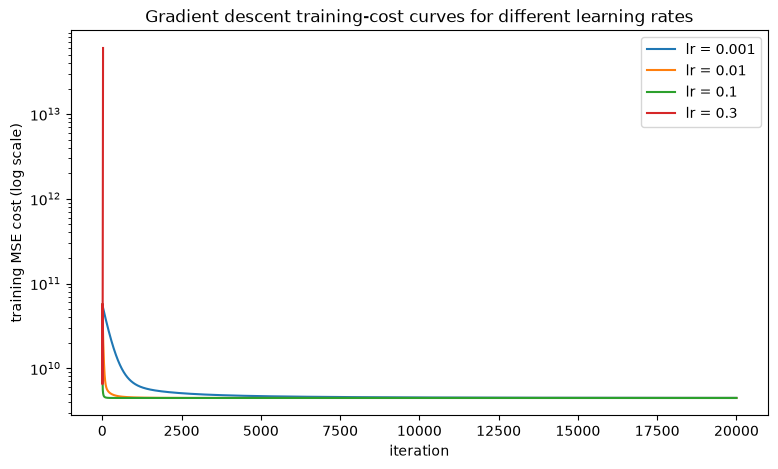

In [15]:
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    # keep only sensible values so a diverged run doesn't wreck the axes
    finite_hist = [h for h in gd_results[lr]["history"] if np.isfinite(h) and h < 1e14]
    plt.plot(finite_hist, label=f"lr = {lr}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("training MSE cost (log scale)")
plt.title("Gradient descent training-cost curves for different learning rates")
plt.legend()
plt.show()

In [16]:
# Pick the best learning rate by validation MSE (ignore any diverged runs)
best_lr = None
best_val = np.inf
for lr in learning_rates:
    v = gd_results[lr]["val_mse"]
    if np.isfinite(v) and v < best_val:
        best_val = v
        best_lr = lr
print(f"best learning rate by validation MSE: {best_lr}  (val MSE = {best_val:.4g})")

best learning rate by validation MSE: 0.1  (val MSE = 4.386e+09)


### Gradient descent for the MAE cost

Same loop, different gradient: J = (1/n) sum |y_i - y_hat_i| is not differentiable at zero error, so we use the subgradient, grad = -(1/n) X^T sign(y - X theta), with sign(0) = 0 (a valid choice in [-1, 1]). Because this gradient has constant magnitude (it does not shrink as we approach the minimum), constant-step subgradient descent ends up hovering around the optimum instead of settling into it, and it needs a much larger step size than the MSE version since the target is in dollars.

In [17]:
def gradient_descent_mae(X, y, lr, n_iters):
    """Batch subgradient descent on the MAE cost."""
    n = len(y)
    theta = np.zeros(X.shape[1])
    history = []
    for it in range(n_iters):
        residual = y - X @ theta
        history.append(np.mean(np.abs(residual)))
        grad = -(1 / n) * (X.T @ np.sign(residual))
        theta = theta - lr * grad
    return theta, history


mae_lrs = [100, 1000, 5000]
mae_results = {}
for lr in mae_lrs:
    theta_lr, hist = gradient_descent_mae(X_train, y_train, lr, 3000)
    val_mae_lr = mae(y_val, predict(X_val, theta_lr))
    mae_results[lr] = {"theta": theta_lr, "history": hist, "val_mae": val_mae_lr}
    print(f"lr = {lr:6}: final train MAE cost = {hist[-1]:.4g},  validation MAE = {val_mae_lr:.4g}")

best_mae_lr = min(mae_results, key=lambda lr: mae_results[lr]["val_mae"])
theta_gd_mae = mae_results[best_mae_lr]["theta"]
print("best MAE-cost learning rate:", best_mae_lr)

lr =    100: final train MAE cost = 5.787e+04,  validation MAE = 5.693e+04


lr =   1000: final train MAE cost = 4.764e+04,  validation MAE = 4.715e+04


lr =   5000: final train MAE cost = 4.758e+04,  validation MAE = 4.714e+04
best MAE-cost learning rate: 5000


In [18]:
# Compare the MSE-loss and MAE-loss models on the validation set
theta_gd_mse = gd_results[best_lr]["theta"]

val_pred_mse_model = predict(X_val, theta_gd_mse)
val_pred_mae_model = predict(X_val, theta_gd_mae)

compare_losses = pd.DataFrame({
    "GD (MSE loss)": all_metrics(y_val, val_pred_mse_model),
    "GD (MAE loss)": all_metrics(y_val, val_pred_mae_model),
})
print("Validation metrics:")
print(compare_losses.round(4).to_string())

Validation metrics:
        GD (MSE loss)  GD (MAE loss)
MSE      4.386104e+09   4.566923e+09
RMSE     6.622766e+04   6.757901e+04
MAE      4.839906e+04   4.713621e+04
R2       6.682000e-01   6.546000e-01
Adj_R2   6.669000e-01   6.532000e-01


**Trade-off:** the MSE-trained model wins on MSE/RMSE and the MAE-trained model wins on MAE, each optimizing exactly the score it was trained for. MSE squares the residuals, so it works hardest on the largest errors (including the censored \$500,001 districts) and its predictions chase the conditional *mean*. MAE weights all residual sizes equally, so it is more robust to outliers and censored values and its predictions chase the conditional *median*, at the price of larger occasional extreme errors. Which loss is right depends on whether big mistakes are disproportionately costly (use MSE) or the data contains outliers you do not want driving the fit (use MAE).

### Final test-set comparison: MMSE vs best gradient descent

In [19]:
# Time the single best-learning-rate GD run, then evaluate both models on the untouched test set
t0 = time.perf_counter()
theta_gd_best, _ = gradient_descent_mse(X_train, y_train, best_lr, n_iters)
gd_time = time.perf_counter() - t0

test_pred_mmse = predict(X_test, theta_mmse)
test_pred_gd = predict(X_test, theta_gd_best)

# L2 norm of the coefficient difference, excluding the intercept (position 0)
coef_diff = np.linalg.norm(theta_mmse[1:] - theta_gd_best[1:])

row_mmse = all_metrics(y_test, test_pred_mmse)
row_mmse["train time (s)"] = mmse_time
row_gd = all_metrics(y_test, test_pred_gd)
row_gd["train time (s)"] = gd_time

final_a = pd.DataFrame({"MMSE closed form": row_mmse, f"GD (lr={best_lr})": row_gd})
print("Test-set comparison:")
print(final_a.round(4).to_string())
print(f"\n||theta_MMSE - theta_GD||_2 (excluding intercept) = {coef_diff:.4f}")

Test-set comparison:
                MMSE closed form   GD (lr=0.1)
MSE                 4.448563e+09  4.448587e+09
RMSE                6.669755e+04  6.669773e+04
MAE                 4.843911e+04  4.844246e+04
R2                  6.644000e-01  6.644000e-01
Adj_R2              6.631000e-01  6.631000e-01
train time (s)      7.000000e-04  8.503000e-01

||theta_MMSE - theta_GD||_2 (excluding intercept) = 41737.5956


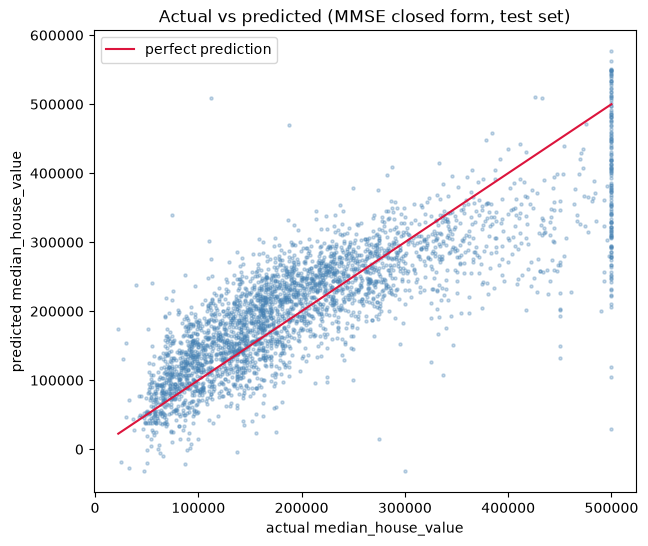

In [20]:
# Actual vs predicted for the better model (MMSE, by test MSE)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred_mmse, s=5, alpha=0.3, color="steelblue")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="crimson", linewidth=1.5, label="perfect prediction")
plt.xlabel("actual median_house_value")
plt.ylabel("predicted median_house_value")
plt.title("Actual vs predicted (MMSE closed form, test set)")
plt.legend()
plt.show()

### Part (a) conclusion

The two approaches reach practically identical test errors, yet the L2 distance between their coefficient vectors is large. This is not a contradiction: the features are strongly correlated (see Part b), so the MSE surface has an almost-flat valley along which many coefficient combinations predict nearly the same values. Gradient descent matches the closed form's *predictions* long before it finishes crawling along that flat valley toward the exact minimizer, so the remaining coefficient difference lies almost entirely in directions the error barely cares about. For a dataset of this size (about 14k training rows, 13 columns), the closed form is preferable: one matrix computation, milliseconds, exact, no learning rate to tune. Gradient descent scales more naturally to much larger data: the closed form must build and (pseudo-)invert X^T X, whose cost grows with the cube of the feature count and needs all data in memory at once, while gradient descent only ever needs matrix-vector products and can process data in mini-batches or streams. That is why closed-form solutions suit small-to-medium tabular problems and gradient methods power everything at large scale.

The actual-vs-predicted plot also shows the censoring artifact: a vertical stripe of districts at the \$500,001 cap that the model scatters predictions around, and a general tendency to under-predict the most expensive districts.

## Part (b): Linear Regression vs Ridge vs Lasso

### Multicollinearity diagnosis

Plain linear regression (the Part (a) MMSE solution is reused as the baseline) is unstable when features are highly correlated: X^T X becomes nearly singular, its inverse amplifies noise, and coefficients can swing wildly between samples while predictions barely change. Two standard diagnostics: the correlation matrix and the condition number of the feature matrix.

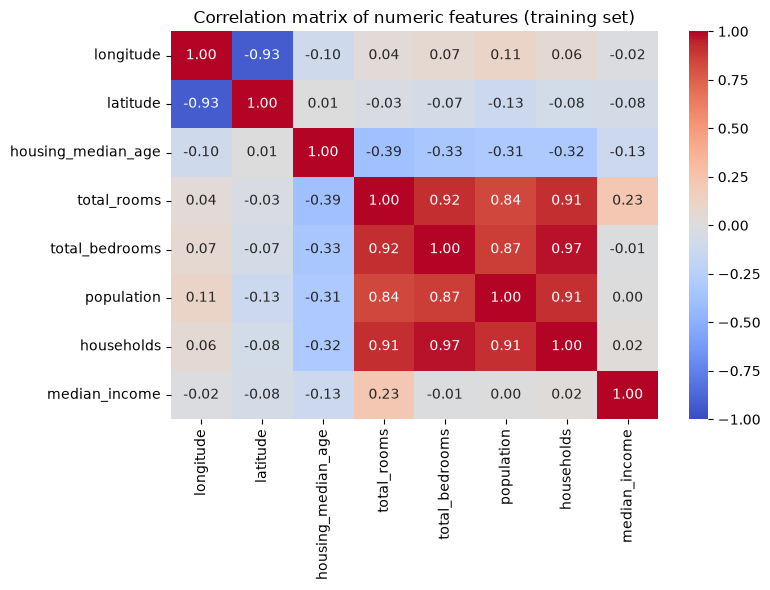

condition number of the training feature matrix (with intercept): 119.0


In [21]:
corr = train_p[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of numeric features (training set)")
plt.tight_layout()
plt.show()

cond_number = np.linalg.cond(X_train)
print(f"condition number of the training feature matrix (with intercept): {cond_number:.1f}")

**Highly correlated groups found:**

1. **The district-size group:** `total_rooms`, `total_bedrooms`, `population`, `households` are all pairwise correlated around 0.9 or higher. All four essentially measure "how big is this district," so they carry nearly the same information four times.
2. **The location pair:** `longitude` and `latitude` are strongly negatively correlated (about -0.92), a geographic accident of California's diagonal coastline.

**Effect on coefficient stability:** with such groups, many different coefficient combinations produce nearly identical predictions (e.g. +10000 on `households` and -9500 on `population` roughly cancel), so the solution is poorly pinned down. Small changes in the training sample can flip signs and magnitudes of these coefficients, which is why individual weights in the Part (a) table should not be interpreted causally. The condition number far above ~30 confirms meaningful multicollinearity; regularization is the standard cure.

### Ridge regression (closed form, intercept not regularized)

theta_ridge = (X^T X + alpha R)^(-1) X^T y with R = diag(0, 1, ..., 1). The zero in R's top-left corner exempts the intercept: we penalize the slopes, not the overall level of prices. Adding alpha to the diagonal also lifts the small eigenvalues of X^T X, directly fixing the conditioning problem.

In [22]:
def fit_ridge(X, y, alpha):
    """Closed-form ridge regression. The intercept (first column) is not regularized."""
    n_params = X.shape[1]
    R = np.eye(n_params)
    R[0, 0] = 0.0
    return np.linalg.pinv(X.T @ X + alpha * R) @ X.T @ y


alphas = [0.1, 1, 10, 100, 1000, 10000, 100000]

print("alpha = 0 (unregularized baseline): validation MSE =", f"{mse(y_val, predict(X_val, theta_mmse)):.4g}")
ridge_thetas = {}
for alpha in alphas:
    theta_r = fit_ridge(X_train, y_train, alpha)
    ridge_thetas[alpha] = theta_r
    v = mse(y_val, predict(X_val, theta_r))
    print(f"alpha = {alpha:8}: validation MSE = {v:.4g}")

best_ridge_alpha = min(ridge_thetas, key=lambda a: mse(y_val, predict(X_val, ridge_thetas[a])))
theta_ridge_best = ridge_thetas[best_ridge_alpha]
print("\nbest ridge alpha by validation MSE:", best_ridge_alpha)

alpha = 0 (unregularized baseline): validation MSE = 4.382e+09
alpha =      0.1: validation MSE = 4.382e+09
alpha =        1: validation MSE = 4.384e+09
alpha =       10: validation MSE = 4.391e+09
alpha =      100: validation MSE = 4.395e+09
alpha =     1000: validation MSE = 4.566e+09
alpha =    10000: validation MSE = 6.486e+09
alpha =   100000: validation MSE = 1.135e+10

best ridge alpha by validation MSE: 0.1


### Lasso regression (sklearn, same positive alpha range)

Lasso minimizes (1/2n)||y - X theta||^2 + alpha ||theta||_1. Note the objectives are on different scales: our ridge penalty is unnormalized while sklearn's lasso divides the squared error by 2n, so the same numeric alpha is a much *stronger* penalty for lasso than for ridge here (roughly a factor of 2n). We share the alpha grid intentionally and account for this scale difference when reading the paths; the two models' alphas should not be expected to align.

In [23]:
from sklearn.linear_model import Lasso

# sklearn fits its own intercept, so we pass the features WITHOUT the ones column
Xtr_nointercept = X_train[:, 1:]
Xva_nointercept = X_val[:, 1:]
Xte_nointercept = X_test[:, 1:]

lasso_models = {}
for alpha in alphas:
    model = Lasso(alpha=alpha, fit_intercept=True, max_iter=100000)
    model.fit(Xtr_nointercept, y_train)
    lasso_models[alpha] = model
    v = mse(y_val, model.predict(Xva_nointercept))
    n_zero = np.sum(model.coef_ == 0)
    print(f"alpha = {alpha:8}: validation MSE = {v:.4g},  zero coefficients: {n_zero}")

best_lasso_alpha = min(lasso_models, key=lambda a: mse(y_val, lasso_models[a].predict(Xva_nointercept)))
lasso_best = lasso_models[best_lasso_alpha]
print("\nbest lasso alpha by validation MSE:", best_lasso_alpha)

alpha =      0.1: validation MSE = 4.382e+09,  zero coefficients: 0
alpha =        1: validation MSE = 4.382e+09,  zero coefficients: 0
alpha =       10: validation MSE = 4.385e+09,  zero coefficients: 0
alpha =      100: validation MSE = 4.397e+09,  zero coefficients: 1
alpha =     1000: validation MSE = 4.473e+09,  zero coefficients: 4
alpha =    10000: validation MSE = 5.708e+09,  zero coefficients: 9
alpha =   100000: validation MSE = 1.322e+10,  zero coefficients: 12

best lasso alpha by validation MSE: 0.1


In [24]:
# Which features does the best lasso model zero out?
zero_features = []
for name, c in zip(feature_cols, lasso_best.coef_):
    if c == 0:
        zero_features.append(name)
print(f"best lasso (alpha = {best_lasso_alpha}) zeroed {len(zero_features)} coefficients:")
print(zero_features if zero_features else "(none)")

print("\nlasso coefficients at the best alpha:")
lasso_coef_table = pd.DataFrame({"feature": feature_cols, "coef": lasso_best.coef_.round(2)})
print(lasso_coef_table.to_string(index=False))

# The best alpha is mild, so also show WHICH features die first as alpha grows
print("\nfeatures zeroed at stronger regularization:")
for alpha in [100, 1000, 10000]:
    dead = []
    for name, c in zip(feature_cols, lasso_models[alpha].coef_):
        if c == 0:
            dead.append(name)
    print(f"  alpha = {alpha:6}: {len(dead)} zeroed -> {dead}")

best lasso (alpha = 0.1) zeroed 0 coefficients:
(none)

lasso coefficients at the best alpha:
                   feature      coef
                 longitude -53564.02
                  latitude -54128.62
        housing_median_age  14078.26
               total_rooms -19398.14
            total_bedrooms  40685.09
                population -50464.71
                households  34077.07
             median_income  77597.33
    ocean_proximity_INLAND -36891.13
    ocean_proximity_ISLAND 125825.74
  ocean_proximity_NEAR BAY  -6916.51
ocean_proximity_NEAR OCEAN   2960.57

features zeroed at stronger regularization:
  alpha =    100: 1 zeroed -> ['ocean_proximity_ISLAND']
  alpha =   1000: 4 zeroed -> ['total_rooms', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
  alpha =  10000: 9 zeroed -> ['longitude', 'latitude', 'total_rooms', 'total_bedrooms', 'population', 'households', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR 

**Why lasso can produce exact zeros and ridge cannot:** ridge's squared penalty has a gradient proportional to the weight itself, so the shrinking force fades as a weight approaches zero and the weight glides toward zero without ever landing on it. Lasso's absolute-value penalty charges the same marginal price all the way down, so for a weak feature the penalty outweighs the fit improvement and the optimum is exactly at the corner theta_j = 0. Geometrically, the L1 constraint region is a diamond whose corners sit on the axes, and optima like corners; the L2 ball is round and has none.

### Coefficient paths

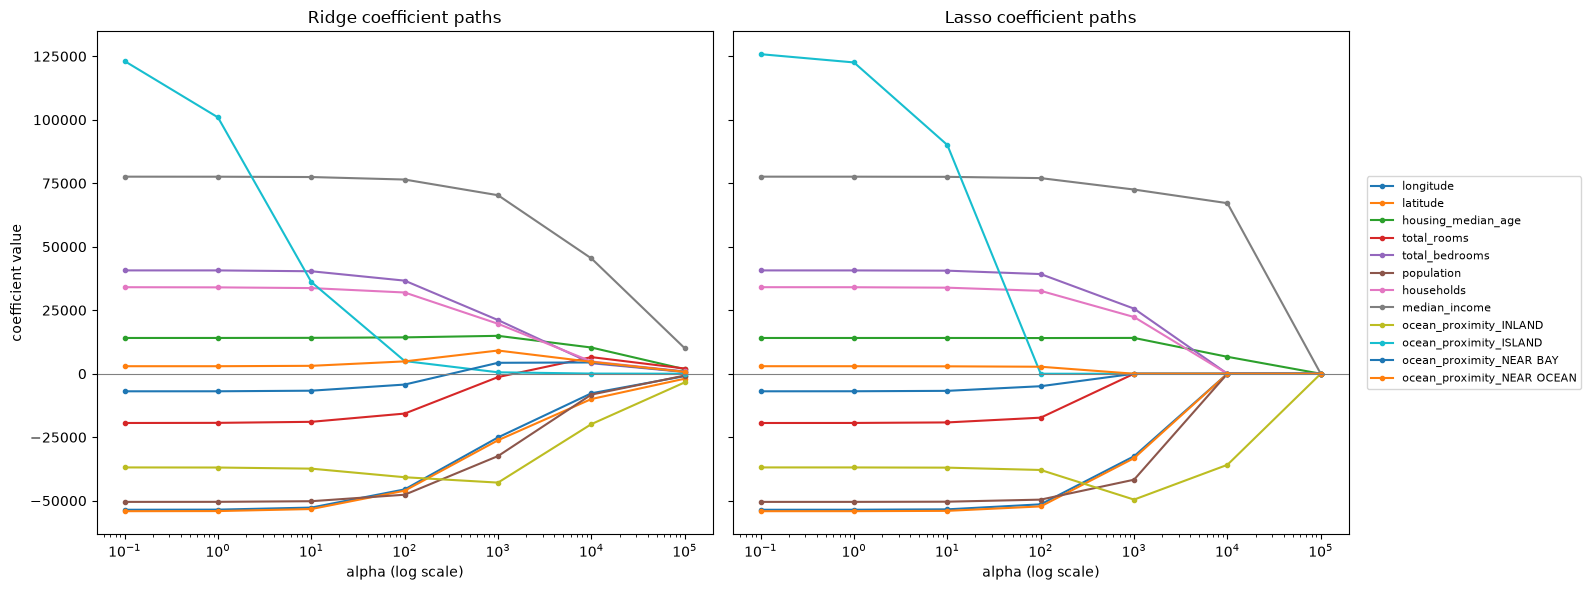

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Ridge path (closed form, exclude intercept)
for j, name in enumerate(feature_cols):
    values = [ridge_thetas[a][j + 1] for a in alphas]
    axes[0].plot(alphas, values, marker="o", markersize=3, label=name)
axes[0].set_xscale("log")
axes[0].set_title("Ridge coefficient paths")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("coefficient value")
axes[0].axhline(0, color="gray", linewidth=0.8)

# Lasso path
for j, name in enumerate(feature_cols):
    values = [lasso_models[a].coef_[j] for a in alphas]
    axes[1].plot(alphas, values, marker="o", markersize=3, label=name)
axes[1].set_xscale("log")
axes[1].set_title("Lasso coefficient paths")
axes[1].set_xlabel("alpha (log scale)")
axes[1].axhline(0, color="gray", linewidth=0.8)

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

**How the paths differ:** ridge shrinks every coefficient *smoothly and simultaneously* toward zero; even at the largest alpha every feature keeps a small nonzero weight, and correlated features (the district-size group) are pulled toward sharing weight. Lasso coefficients instead hit exactly zero one after another as alpha grows, effectively performing feature selection, and among correlated features it tends to keep one representative and delete the rest. The lasso paths also collapse at much smaller alpha values than ridge's visibly move; that is the objective-scale difference noted above (lasso's alpha is effectively multiplied by ~2n relative to our unnormalized ridge), not a difference in the underlying behaviour.

### Final test-set comparison

In [26]:
def summarize(name, y_hat, coefs_no_intercept):
    row = all_metrics(y_test, y_hat)
    row["||theta||_2 (no intercept)"] = np.linalg.norm(coefs_no_intercept)
    row["nonzero coefs"] = int(np.sum(coefs_no_intercept != 0))
    return pd.Series(row, name=name)

rows = []
rows.append(summarize("Linear (MMSE)", predict(X_test, theta_mmse), theta_mmse[1:]))
rows.append(summarize(f"Ridge (a={best_ridge_alpha})", predict(X_test, theta_ridge_best), theta_ridge_best[1:]))
rows.append(summarize(f"Lasso (a={best_lasso_alpha})", lasso_best.predict(Xte_nointercept), lasso_best.coef_))

final_b = pd.DataFrame(rows)
print(final_b.round(4).to_string())

                        MSE        RMSE         MAE      R2  Adj_R2  ||theta||_2 (no intercept)  nonzero coefs
Linear (MMSE)  4.448563e+09  66697.5479  48439.1139  0.6644  0.6631                 187348.6638           12.0
Ridge (a=0.1)  4.448566e+09  66697.5693  48439.3055  0.6644  0.6631                 185281.8002           12.0
Lasso (a=0.1)  4.448563e+09  66697.5518  48439.1387  0.6644  0.6631                 187103.5236           12.0


### Part (b) discussion

On this dataset all three models test within a whisker of each other: with ~14k training rows and only 12 predictors, the data overwhelms the mild multicollinearity, so the unregularized fit was never in real danger of overfitting and regularization mostly trades a tiny bit of bias for a smaller coefficient norm. Concretely, our best ridge alpha shrinks the coefficient L2 norm visibly at essentially unchanged test error, and lasso additionally switches off its weakest features while matching the others' performance.

**When to prefer which:** plain linear regression when observations far outnumber well-conditioned features and interpretation of unbiased coefficients matters, as here. Ridge when features are many or strongly correlated and you want to keep them all but stabilize the fit: a real-world example is genomics, where thousands of correlated gene-expression features each carry a little signal and ridge shares weight across them instead of arbitrarily picking one. Lasso when you suspect only a few features truly matter and want the model to say which: for example, in marketing-mix modelling with hundreds of candidate channels and campaign variables, lasso produces a short interpretable list of drivers by zeroing the rest. A practical middle ground is Elastic Net, which mixes both penalties.